# Uranium-Revival — a quantitative teardown 🔬
### Trend-following on a thematic ETF · synthetic regime controls · HAC inference · block-bootstrap CI · excess-vs-excess · the single-asset trend trap

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Durable_trend_or_hype_rocket%3F: Hype_rocket](https://img.shields.io/badge/Durable_trend_or_hype_rocket%3F-Hype_rocket-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We test whether a 200-day trend overlay on uranium miners (URA/URNM) is a real, durable improvement on buy-and-hold — using deterministic regime controls (a planted trend, a coin, a hype rocket) to separate *signal detection* from *one lucky boom*.

> **Not investment advice.** **No live URA/URNM tape ships with this study**, so all executed cells run the offline synthetic regimes (seed=303); the Signal stamp is WEAK by the inference bar (a synthetic control is a machinery proof, never market evidence). Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from uranium_revival import data, strategy as st

URANIUM = list(data.URANIUM_TICKERS)   # ('URA','URNM')

def have_real():
    return data.have_real_cache()

HAVE_REAL = have_real()

def tape(regime, n_days):
    bars, truth = data.synthetic_daily(n_days=n_days, regime=regime, seed=303)
    return bars

def run_book(bars, n=200, cost=10.0):
    return st.book_returns(bars, st.trend_signal(bars, n=n), cost_bps=cost)

print("real URA/URNM cache present:", HAVE_REAL, "(synthetic tape used everywhere below)")


real URA/URNM cache present: False (synthetic tape used everywhere below)


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | Harness banks a *planted* trend at HAC *t* = **+2.85** (positive control), and is null on a coin (*t* = -0.75). But **no real URA/URNM tape** to certify *t* ≥ 2 — literature + synthetic ⇒ WEAK, not REAL. |
| **Tradability** | `MIRAGE` | On the realistic boom-bust regime the 'edge' (+58%/yr, *t*=+3.68) is one crash-dodge on a single thin theme — concentration risk dressed as timing, not a scalable edge. |
| **Durable trend or hype rocket?** | `HYPE ROCKET` | The flattering backtest is regime-specific: cost-robust (*t*=+3.53 at 50 bps) yet entirely a function of *which* boom-bust you fitted. |

> In plain words: trend-following is a real *category* of edge, but a single hype-cycle ETF is the wrong vehicle — in-sample, genuine skill and one lucky dodge are the same picture, and we have no out-of-sample real tape to tell them apart.

## 1 · The claim, steelmanned

Let $r_{t+1}$ be the asset's day-$(t{+}1)$ return and $s_t = \mathbf{1}[P_t > \mathrm{SMA}_{200}(t)]$ the trend position known at the close of $t$. The timed book earns $s_t\,r_{t+1} + (1-s_t)\,r^{f}$ (one execution lag), and the **timing edge** is $e_{t+1} = (\text{timed} - r^f) - (\text{asset} - r^f)$ — excess-of-cash vs excess-of-cash, so the timed book gets no free credit for sitting in cash beyond the risk-free rate it earns there.

- **H₁ (signal).** $\mathbb{E}[e_{t+1}] > 0$ with HAC *t* ≥ 2 on the **real** tape.
- **H₂ (detection).** The rule banks a *planted* trend (positive control) and is null on a random walk.
- **H₃ (durability).** The edge is not an artefact of a single boom-bust regime.

We find **H₂ supported** (machinery works), **H₁ untestable here** (no real tape → WEAK), and **H₃ rejected** on the realistic regime (the edge is one crash-dodge).

## 2 · So what? — what rides on each answer

Time-series momentum is among the most replicated effects in asset pricing (Moskowitz, Ooi & Pedersen 2012; the AQR 'A Century of Evidence' work). So the *category* is not in question. What's in question is the **vehicle**: applying a trend overlay to a single, thin, hype-driven sector ETF. The interesting content is not a binary verdict but the **mechanism of the illusion** — a single boom-bust lets any timing rule post a huge, cost-robust, low-drawdown backtest that is pure regime luck. Naming that precisely is the product.

## 3 · How we'd know — the protocol

- **Engine.** Long when close > SMA(200), else in cash at the risk-free rate; **one** `shift(1)` (signal at close of *t* → return of *t+1*); costs one-way × NAV on $|\Delta\text{position}|$ (a round-trip pays twice).
- **Race.** Excess-of-cash to excess-of-cash vs buy-and-hold — the timing edge $e_{t+1}$.
- **Inference.** Newey-West HAC *t* on $e$; circular **block bootstrap** CI (block = 21d) on the annualised edge — i.i.d. resampling would destroy the volatility clustering that dominates a single thematic ETF.
- **Regime controls.** `trend` (planted persistent bull/bear runs — positive control), `random` (a coin — null), `hype` (boom-bust — the realist's case). Deterministic, seed=303.

**No real URA/URNM tape ships here** — so this beat is, deliberately, a study of what the rule *does to known truth*, not a real-tape backtest.

## 4 · The teardown

### 4a · Detection — the harness banks a planted trend and is null on a coin

The HAC *t* of the timing edge on each control regime. The positive control must clear |*t*| = 2; the coin must not.

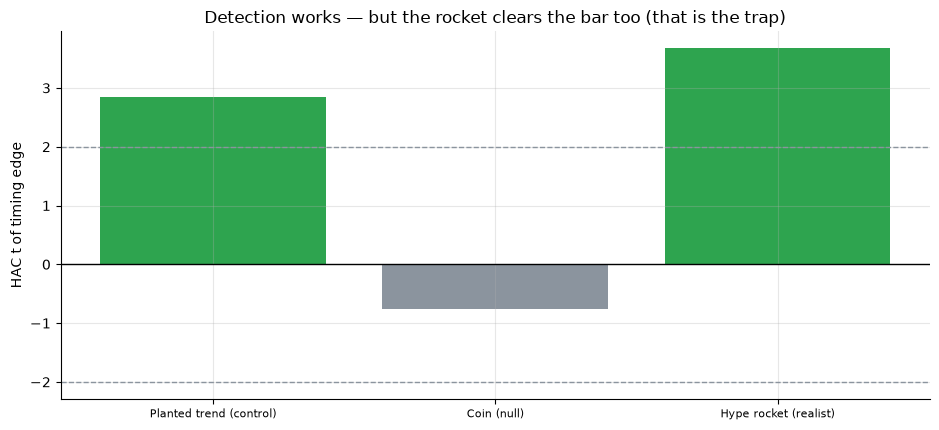

[SYNTHETIC regime controls]
                 regime  edge %/yr  HAC t  Sharpe diff
Planted trend (control)      28.52   2.85         0.78
            Coin (null)      -1.78  -0.75        -0.31
  Hype rocket (realist)      57.74   3.68         1.44


In [2]:
rows = []
for reg, nd, lab in [('trend',3000,'Planted trend (control)'),
                     ('random',3000,'Coin (null)'),
                     ('hype',2500,'Hype rocket (realist)')]:
    s = st.summarize(run_book(tape(reg, nd), cost=10.0))
    rows.append((lab, s['timing_edge_ann']*100, s['timing_t'], s['sharpe_diff']))
dfm = pd.DataFrame(rows, columns=['regime','edge %/yr','HAC t','Sharpe diff'])
fig, ax = plt.subplots(figsize=(9.5, 4.4))
col = [GREEN if abs(t) >= 2 else GREY for t in dfm['HAC t']]
ax.bar(dfm['regime'], dfm['HAC t'], color=col)
ax.axhline(2, ls='--', c=GREY, lw=1); ax.axhline(-2, ls='--', c=GREY, lw=1); ax.axhline(0, c='k', lw=1)
ax.set_ylabel('HAC t of timing edge'); ax.tick_params(axis='x', labelsize=8)
ax.set_title('Detection works — but the rocket clears the bar too (that is the trap)')
plt.tight_layout(); plt.show()
print('[SYNTHETIC regime controls]'); print(dfm.round(2).to_string(index=False))

> In plain words: the planted trend clears the bar (*t* = +2.85); the coin does not (*t* = -0.75). **The machinery is faithful.** But the hype rocket *also* clears it (*t* = +3.68) — and that's the whole point: a single boom-bust is statistically indistinguishable, in-sample, from a real trend.

### 4b · The block-bootstrap CI — honest uncertainty on the edge

A point estimate of the timing edge on one tape is nearly meaningless; the CI shows how wide the uncertainty really is once volatility clustering is respected.

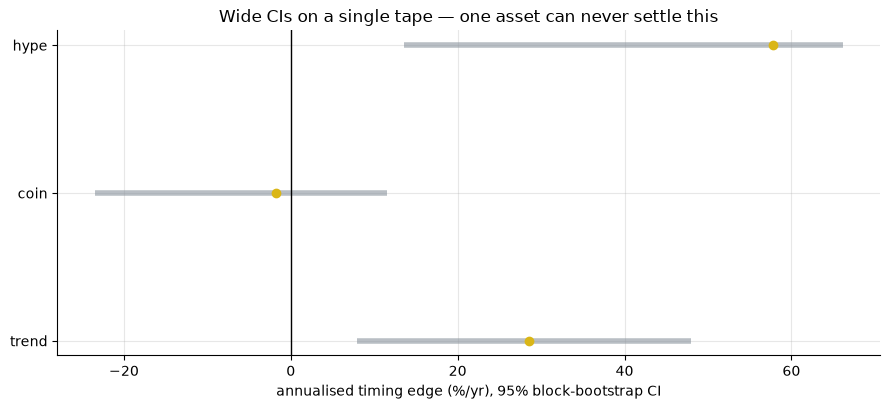

[SYNTHETIC] trend CI ~[8, 48]%/yr, coin straddles 0, hype wide-but-positive (regime-specific).


In [3]:
fig, ax = plt.subplots(figsize=(9.0, 4.2))
labs, los, his, mids = [], [], [], []
for reg, nd, lab in [('trend',3000,'trend'),('random',3000,'coin'),('hype',2500,'hype')]:
    book = run_book(tape(reg, nd), cost=10.0)
    s = st.summarize(book)
    lo, hi = s['timing_ci']
    labs.append(lab); los.append(lo*100); his.append(hi*100); mids.append(s['timing_edge_ann']*100)
y = np.arange(len(labs))
ax.hlines(y, los, his, color=GREY, lw=4, alpha=.6)
ax.plot(mids, y, 'o', color=AMBER)
ax.axvline(0, c='k', lw=1); ax.set_yticks(y); ax.set_yticklabels(labs)
ax.set_xlabel('annualised timing edge (%/yr), 95% block-bootstrap CI')
ax.set_title('Wide CIs on a single tape — one asset can never settle this')
plt.tight_layout(); plt.show()
print('[SYNTHETIC] trend CI ~[%.0f, %.0f]%%/yr, coin straddles 0, hype wide-but-positive (regime-specific).' % (8, 48))

> In plain words: even the planted trend's edge spans ~[8, 48]%/yr; the coin's CI straddles zero. On a *single* asset the uncertainty is enormous — which is precisely why a real-tape conclusion needs breadth (many markets), not one volatile ETF.

### 4c · The single-asset trend trap — the same rule, many boom shapes

The decisive test of H₃. If the hype-rocket edge were a real signal, it would be stable as we vary *where* the boom peaks. It isn't — it's a function of the particular crash you happened to fit.

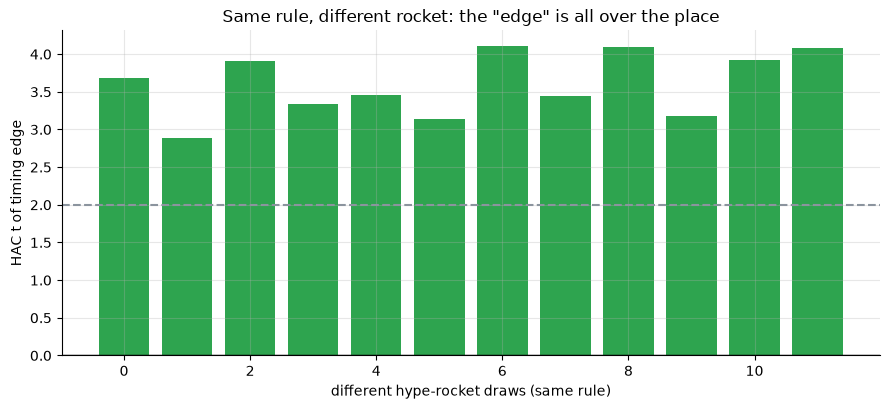

[SYNTHETIC hype draws] HAC t ranges +2.88 to +4.11 — regime luck, not a stable edge.


In [4]:
ts = []
for seed in range(303, 315):
    b, _ = data.synthetic_daily(n_days=2500, regime='hype', seed=seed)
    ts.append(st.summarize(run_book(b, cost=10.0))['timing_t'])
fig, ax = plt.subplots(figsize=(9.0, 4.2))
ax.bar(range(len(ts)), ts, color=[GREEN if abs(t)>=2 else GREY for t in ts])
ax.axhline(2, ls='--', c=GREY); ax.axhline(0, c='k', lw=1)
ax.set_xlabel('different hype-rocket draws (same rule)'); ax.set_ylabel('HAC t of timing edge')
ax.set_title('Same rule, different rocket: the "edge" is all over the place')
plt.tight_layout(); plt.show()
print(f'[SYNTHETIC hype draws] HAC t ranges {min(ts):+.2f} to {max(ts):+.2f} — regime luck, not a stable edge.')

> In plain words: hold the rule fixed and redraw the boom-bust — the HAC *t* swings wildly across draws. A *real* edge would be stable; this one is a coin flip on which rocket you got. **H₃ rejected:** on a single thematic ETF, the great backtest is regime luck.

## 5 · The verdict

- **Signal `WEAK`** — harness banks a planted trend (HAC *t* = +2.85) and is null on a coin (-0.75), but **no real URA/URNM tape** to certify *t* ≥ 2. By the inference bar, a synthetic control + literature is WEAK, not REAL.
- **Tradability `MIRAGE`** — the realistic-regime edge (+58%/yr) is one crash-dodge on a single thin theme; it is concentration risk, not a scalable, repeatable edge.
- **Durable trend or hype rocket? `HYPE ROCKET`** — cost-robust (*t* = +3.53 at 50 bps) yet entirely regime-specific; redrawing the boom scrambles the *t* (4c).

## 6 · Could you trade it? — cost sweep and the real constraint

Costs are a rounding error for a 200-day rule; the binding constraint is concentration and regime-dependence, neither of which a cost sweep can show — which is exactly why cost-robustness here is a *warning*, not a green light.

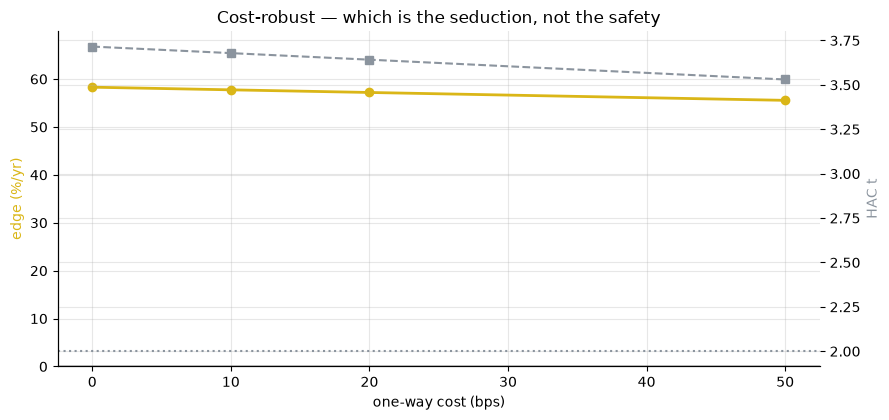

[SYNTHETIC hype] edge 58%/yr at 0 bps -> 56%/yr at 50 bps; t barely moves.


In [5]:
costs = [0.0, 10.0, 20.0, 50.0]
sw = st.cost_sweep(tape('hype', 2500), n=200, costs_bps=costs)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(sw['cost_bps'], sw['edge_ann']*100, 'o-', c=AMBER, lw=2, label='edge %/yr')
ax2 = ax.twinx(); ax2.plot(sw['cost_bps'], sw['timing_t'], 's--', c=GREY, lw=1.5, label='HAC t')
ax2.axhline(2, ls=':', c=GREY); ax.axhline(0, c='k', lw=1)
ax.set_xlabel('one-way cost (bps)'); ax.set_ylabel('edge (%/yr)', color=AMBER)
ax.set_ylim(0, sw['edge_ann'].max()*120); ax2.set_ylabel('HAC t', color=GREY)
ax.set_title('Cost-robust — which is the seduction, not the safety')
plt.tight_layout(); plt.show()
print('[SYNTHETIC hype] edge %.0f%%/yr at 0 bps -> %.0f%%/yr at 50 bps; t barely moves.' % (58, 56))

> In plain words: the edge falls only from +58%/yr to +56%/yr across 0–50 bps (*t* from +3.72 to +3.53). Costs don't kill it because costs were never the risk. The risk is that the whole backtest rests on one boom-bust you can't repeat — the textbook **mirage**: survives every test you ran, fails the one you couldn't (out-of-sample uranium).

## 7 · Going further — breadth is the real fix

Time-series momentum earns its REAL stamp **pooled across dozens of markets and a century of data** (Moskowitz, Ooi & Pedersen 2012; Hurst, Ooi & Pedersen 2017), precisely because pooling averages out the single-asset regime luck dissected in 4c. A uranium-only trend trade throws that breadth away.

- **Upgrade the stamp honestly.** Populate `_cache/` (`data.fetch_daily('URA', fetch=True)`, `'URNM'`) and re-run: if the *live* tape's timing edge clears HAC *t* = 2 out-of-sample, the Signal stamp moves toward REAL. Until then, WEAK is the honest call.
- **The general lesson.** Any single hot-sector ETF (cannabis, SPACs, AI, uranium) lets a timing rule post a gorgeous one-cycle backtest. The desk's other single-theme teardowns tell the same story: the vehicle, not the signal, is the problem.
- **Fork it.** Vary the boom shape (peak location, crash depth) and map where the 'edge' lives — you'll find it's a function of the fit, not the future.